
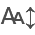

In [167]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, precision_score, f1_score, fbeta_score
from sklearn.model_selection import RandomizedSearchCV
import shap
import random

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

In [80]:
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

ustawienie ziarna globalnie

In [126]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [127]:
df = pd.read_csv(os.path.join(processed_data_input_path, 'initial_features_selected.csv'))

df = df.set_index('Unnamed: 0')
df.index.name = None
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [128]:
benchmark_cols = [
    'season',
    'gameweek',
    'team',
    'opponent',
    'goals_scored',
    'goals_conceded',
    'prob_unexpected_result',
    'elo_unexpected_result',
    'win_probability',
    'draw_probability',
    'not_loss_probability',
    'win_odds',
    'draw_odds',
    'loss_odds'
]
df_benchmark = df[benchmark_cols].copy()
benchmark_cols.remove('prob_unexpected_result')
df = df.drop(columns=benchmark_cols)

df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Podział na zbiory - treningowy, walidacyjny, testowy (70/15/15)

In [141]:
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

# Skalowanie danych
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.iloc[:,:-4]), columns=df.columns[:-4])
df_scaled.index = df.index
                         
df_scaled = pd.concat([df_scaled, df.iloc[:,-4:]], axis=1)

X_train = df_scaled.iloc[:train_end, :-1]
y_train = df_scaled.iloc[:train_end, -1]

X_val = df_scaled.iloc[train_end:val_end, :-1]
y_val = df_scaled.iloc[train_end:val_end, -1]

X_trainval = df_scaled.iloc[:val_end, :-1]
y_trainval = df_scaled.iloc[:val_end, -1]

X_test = df_scaled.iloc[val_end:, :-1]
y_test = df_scaled.iloc[val_end:, -1]   
# X_train = df.iloc[:train_end, :-1]
# y_train = df.iloc[:train_end, -1]

# X_val = df.iloc[train_end:val_end, :-1]
# y_val = df.iloc[train_end:val_end, -1]

# X_trainval = df.iloc[:val_end, :-1]
# y_trainval = df.iloc[:val_end, -1]

# X_test = df.iloc[val_end:, :-1]
# y_test = df.iloc[val_end:, -1]   

# df_trainval = deepcopy(df_features.iloc[:val_end])
# df_trainval['match_id'] = df_trainval.index // 2


X_train

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Utworzenie wstępnego modelu do określenia istotności cech

In [160]:
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

# Opakowanie modelu
clf1 = KerasClassifier(
    model=create_model, 
    input_dim=X_train.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42)
# clf = create_model(X_train)
clf1.fit(X_train, y_train)


KerasClassifier(
	model=<function create_model at 0x0000019F62BA36A0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=71
	class_weight=None
)

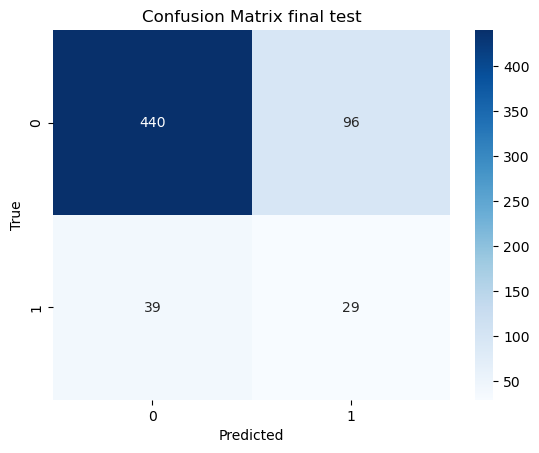

              precision    recall  f1-score   support

           0      0.919     0.821     0.867       536
           1      0.232     0.426     0.301        68

    accuracy                          0.776       604
   macro avg      0.575     0.624     0.584       604
weighted avg      0.841     0.776     0.803       604

ROC AUC: 0.493


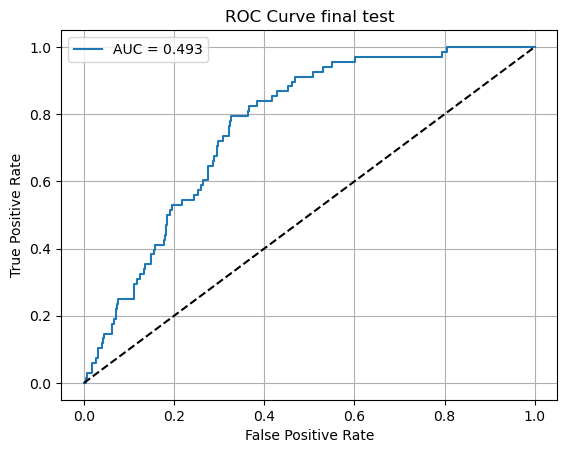

In [161]:
y_prob1 = clf1.predict_proba(X_val)[:, 1]
y_pred1 = (y_prob1 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred1, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_test, y_prob1)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob1)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

Sprawdzenie istotności cech korzystając ze zbioru walidacyjnego

PermutationExplainer explainer: 605it [16:48,  1.67s/it]                         


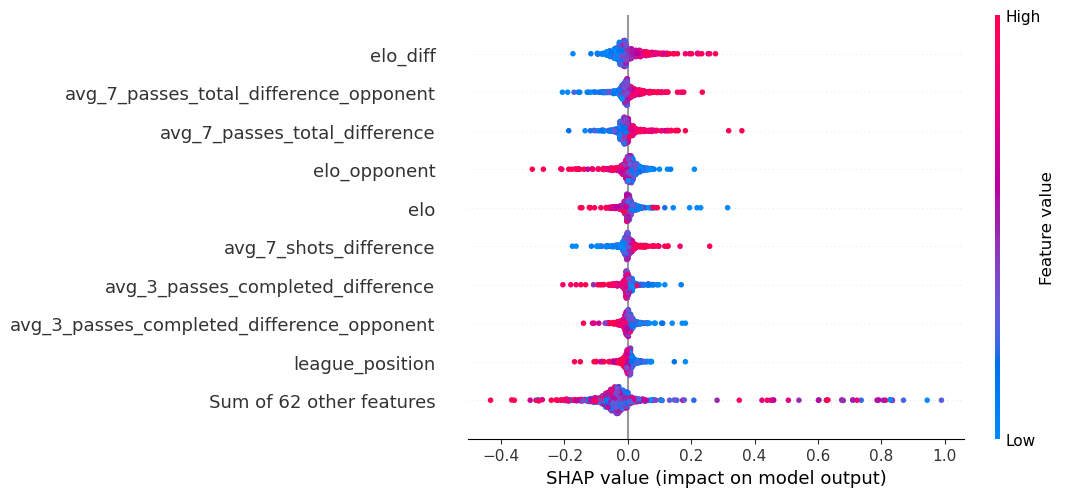

In [16]:
explainer = shap.Explainer(clf1.predict, X_val)  # clf to Twoja sieć
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)

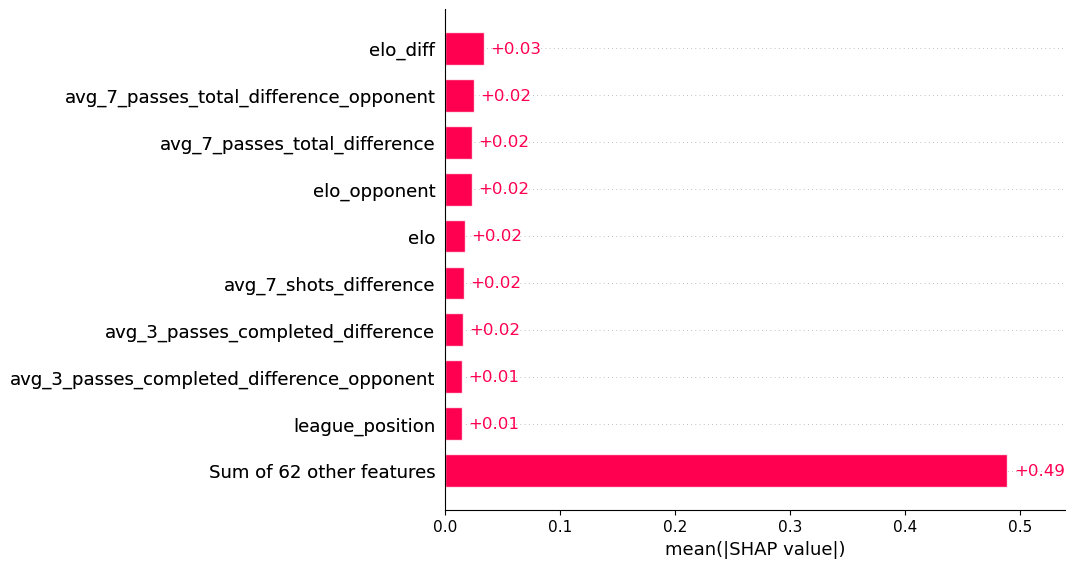

In [20]:
shap.plots.bar(shap_values)

Krosswalidacja modeli tworzonych na podstawie n najistotniejszych cech wg SHAP w celu selekcji cech

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.base import clone


def model_CV(X, y, n_split=5):
    tscv = TimeSeriesSplit(n_splits=n_split)
    scores = []
    i = 1
    for train_idx, val_idx in tscv.split(X.index):
        print(f"fold {i}")
        # Podział danych
        X_train_CV, X_val_CV = X.iloc[train_idx], X.iloc[val_idx]
        y_train_CV, y_val_CV = y.iloc[train_idx], y.iloc[val_idx]

        # Opakowanie modelu
        clf_fold = KerasClassifier(
            model=create_model, 
            input_dim=X_train_CV.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
            epochs=10, 
            batch_size=32,
            verbose=0, 
            shuffle=False, 
            random_state=42)
        # clf = create_model(X_train)

        # 🏋️‍♂️ Trening
        clf_fold.fit(X_train_CV, y_train_CV, epochs=20, batch_size=32, verbose=0)

        # 🔍 Predykcja i metryka
        y_prob_CV = clf_fold.predict_proba(X_val_CV)[:, 1]
        y_pred_CV = (y_prob_CV > 0.2).astype(int)  
        
        score = f1_score(y_val_CV, y_pred_CV)
        
        scores.append(score)
        i += 1
    return pd.Series(scores)

def shap_feature_selection(X, y, model, shap_vals, steps, scoring='f1'):

    mean_abs = np.abs(shap_vals.values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]  # od najważniejszych

    mean_shap_df = pd.DataFrame(data={
        'feature': shap_vals.feature_names,
        'mean_abs_shap': mean_abs
    })

    results = []
    for k in steps:
        print(f"{k} features")
        keep_idx = order[:k]
        X_sel = X.iloc[:, keep_idx]

        scores = model_CV(X_sel, y, n_split=5)
        results.append({
            "n_features": k,
            "mean_score": scores.mean(),
            "std_score": scores.std(),
            "max_score": scores.max(),
            "features": list(X_sel.columns)
        })
    return results, mean_shap_df
n_features = [40, 50,55, 58, 60, 62, 65,len(X_val.columns)]
results, mean_shap_df = shap_feature_selection(X_train, y_train, clf1, shap_values, n_features)

40 features
fold 1
fold 2
fold 3
fold 4
fold 5
50 features
fold 1
fold 2
fold 3
fold 4
fold 5
55 features
fold 1
fold 2
fold 3
fold 4
fold 5
58 features
fold 1
fold 2
fold 3
fold 4
fold 5
60 features
fold 1
fold 2
fold 3
fold 4
fold 5
62 features
fold 1
fold 2
fold 3
fold 4
fold 5
65 features
fold 1
fold 2
fold 3
fold 4
fold 5
71 features
fold 1
fold 2
fold 3
fold 4
fold 5


In [137]:
cols = results[4]['features']

In [144]:
X_train2 = X_train[cols]
X_val2 = X_val[cols]
X_test2 = X_test[cols]

Sprawdzenie działania modelu po selekcji cech

In [162]:
clf2 = KerasClassifier(
    model=create_model, 
    input_dim=X_train2.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42)
# clf = create_model(X_train)
clf2.fit(X_train2, y_train)


KerasClassifier(
	model=<function create_model at 0x0000019F62BA36A0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=60
	class_weight=None
)

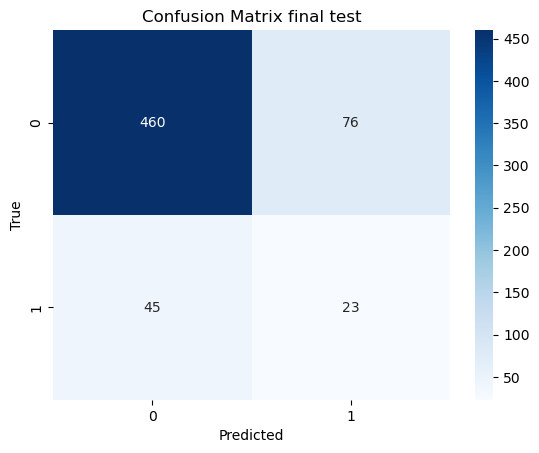

              precision    recall  f1-score   support

           0      0.911     0.858     0.884       536
           1      0.232     0.338     0.275        68

    accuracy                          0.800       604
   macro avg      0.572     0.598     0.580       604
weighted avg      0.834     0.800     0.815       604

ROC AUC: 0.542


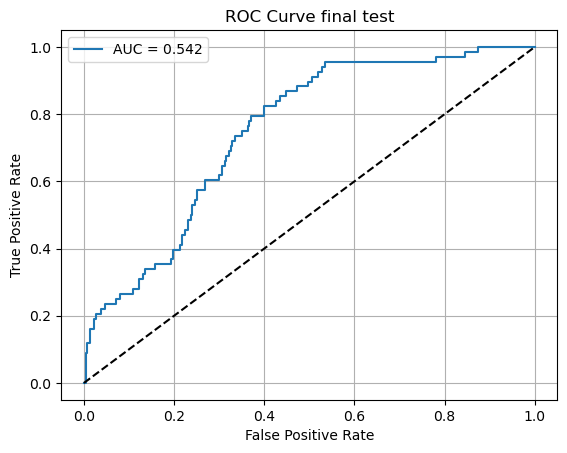

In [163]:
y_prob2 = clf2.predict_proba(X_val2)[:, 1]
y_pred2 = (y_prob2 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred2, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_test, y_prob2)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob2)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
f05_scorer = make_scorer(fbeta_score, beta=0.4, pos_label=1)

In [165]:
def create_model_optimized(input_dim, dropout_rate, dense1_units, dense2_units):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(dense1_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(dense2_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


In [173]:
clf_opt = KerasClassifier(model=create_model_optimized, verbose=0, shuffle=False, random_state=42)

param_dist = {
    "input_dim": X_train2.shape[1],  # nie tuninguje się
    "batch_size": [16, 32, 64],
    "epochs": [50, 100],
    "dropout_rate": [0.2, 0.3, 0.4],  # musisz dodać dropout_rate jako parametr create_model
    "dense1_units": [64, 128, 256],
    "dense2_units": [32, 64],
}

search = RandomizedSearchCV(clf_opt, param_distributions=param_dist, cv=5, scoring="f1", n_iter=100)
search.fit(X_train2, y_train)

TypeError: Parameter grid for parameter 'input_dim' is not iterable or a distribution (value=60)